# 2.2 Filtering and groupby

:::{admonition} Lesson Content
:class: note, dropdown

- 🗑️ Filtering
- 📍 Setting an Index
- 🔪 Groupby

:::

## Context

We spent yesterday getting comfortable in `pandas`. We opened some data, explored it, and ran a few functions.  Today we are going to expand on what we are doing by learning a few powerful ways to interrogate our data -- filtering and grouping.  These manipulations help us get at the specific part of a dataset that we need.

### Loading our data

In this lesson we will be using data from the Picarro instrument onboard a 2024 SARP flight.

https://www-air.larc.nasa.gov/cgi-bin/ArcView/sarp.2024?DA-B200=1

In [1]:
import pandas as pd

# This line shortens the output
pd.set_option('display.max_rows', 8)

File format: The file below is an icartt file. This file is specifically designed for flight data

In [2]:
picarro_flight = pd.read_csv('./data/SARP-PICARRO-GHG-SLOW_DA-B200_20240702_R0_L1.ict')

ParserError: Error tokenizing data. C error: Expected 2 fields in line 7, saw 6


icartt files store metadata in the first few lines of the file. This metadata information is useful to read through, but isn't used by pandas for creating the dataframe. What we need to do is let pandas know that it should skip past those first few lines of metadata. We do that with the `skiprows` argument.

In [3]:
picarro_flight = pd.read_csv(
    './data/SARP-PICARRO-GHG-SLOW_DA-B200_20240702_R0_L1.ict',
    skiprows=50,
)

In [4]:
picarro_flight

,50535.78,50537.78,-9999.000,-9999.00000,-9999,-9999.0,-9999.000000,-9999.000000.1,-9999.000000.2
0,50537.78,50539.78,-9999.0,-9999.0,-9999,-9999.0,-9999.000000,-9999.000000,-9999.000000
1,50539.78,50541.78,-9999.0,-9999.0,-9999,-9999.0,-9999.000000,-9999.000000,-9999.000000
2,50541.78,50543.78,-9999.0,-9999.0,-9999,-9999.0,-9999.000000,-9999.000000,-9999.000000
3,50543.78,50545.78,-9999.0,-9999.0,-9999,-9999.0,-9999.000000,-9999.000000,-9999.000000
...,...,...,...,...,...,...,...,...,...
7272,65081.78,65083.78,-9999.0,-9999.0,-9999,-9999.0,303.472604,-117.612087,34.051407
7273,65083.78,65085.78,-9999.0,-9999.0,-9999,-9999.0,303.305524,-117.612095,34.051402
7274,65085.78,65087.78,-9999.0,-9999.0,-9999,-9999.0,303.175135,-117.612098,34.051393
7275,65087.78,65089.78,-9999.0,-9999.0,-9999,-9999.0,303.044566,-117.612098,34.051386


What have we got? Well we've made progress in that we have read the file without errors. Notice the column names, however. Those look like data values, not column names. It appears as though we have skipped too many rows. But how do we know how many rows to skip without reading the file?

**Option 1: Open the file outside Python**

Because icartt files are csv files they can be opened in any csv viewer. Cryocloud has a csv viewer built in, or you can use excel if you are on you computer. Double click the file to open it.

![ICARRT File Viewer](./images/icartt_header.png)

We can see on that first line the number 41. That 41 tells us that the data header is on line 41 of the file. So, if we skip the first 40 rows of data we should start exactly where we want. Let's try it out:

In [5]:
picarro_flight = pd.read_csv(
    './data/SARP-PICARRO-GHG-SLOW_DA-B200_20240702_R0_L1.ict',
    skiprows=40,
)

In [6]:
picarro_flight

,Time_Start,Time_Stop,CO2_ppm,CH4_ppm,H2O_ppm,CO_ppb,GPS_Alt,GPS_Lon,GPS_Lat
0,50517.78,50519.78,-9999.0,-9999.0,-9999,-9999.0,-9999.000000,-9999.000000,-9999.000000
1,50519.78,50521.78,-9999.0,-9999.0,-9999,-9999.0,-9999.000000,-9999.000000,-9999.000000
2,50521.78,50523.78,-9999.0,-9999.0,-9999,-9999.0,-9999.000000,-9999.000000,-9999.000000
3,50523.78,50525.78,-9999.0,-9999.0,-9999,-9999.0,-9999.000000,-9999.000000,-9999.000000
...,...,...,...,...,...,...,...,...,...
7282,65081.78,65083.78,-9999.0,-9999.0,-9999,-9999.0,303.472604,-117.612087,34.051407
7283,65083.78,65085.78,-9999.0,-9999.0,-9999,-9999.0,303.305524,-117.612095,34.051402
7284,65085.78,65087.78,-9999.0,-9999.0,-9999,-9999.0,303.175135,-117.612098,34.051393
7285,65087.78,65089.78,-9999.0,-9999.0,-9999,-9999.0,303.044566,-117.612098,34.051386


Beautiful! Our raw data.

**(intermediate) Option 2: Use Python to read the first line**

On smaller files its fine to open them in a csv reader. Larger files, though, will struggle to render in Cryocloud and even in excel. To perform the same check programmatically we can use Python to read the file:

In [7]:
with open('./data/SARP-PICARRO-GHG-SLOW_DA-B200_20240702_R0_L1.ict') as f:
    firstline = f.readline()

print(firstline)

41, 1001



There we have the same information as we found manually -- the magic `41` that tells use we need to skip `40` rows of metadata information.

Next we are going to do a bit of data cleaning to get our dataset ready for the rest of the lesson.

In [8]:
from datetime import datetime, timedelta

import numpy as np

In [9]:
# Fill -9999 with NaN
picarro_flight.replace(-9999, np.nan, inplace=True)
# Remove any rows before data started to be collected
picarro_flight = picarro_flight[~picarro_flight[' CO2_ppm'].isnull()]
picarro_flight.reset_index(drop=True, inplace=True)
# Convert the star time to a datetime and insert it as the first column in the dataframe
picarro_flight.insert(0, 'datetime (UTC)', picarro_flight.apply(
    lambda row: datetime(2024, 7, 2) + timedelta(seconds=round(row['Time_Start'])), 
    axis=1
))

The cleaned data:

In [10]:
picarro_flight

,datetime (UTC),Time_Start,Time_Stop,CO2_ppm,CH4_ppm,H2O_ppm,CO_ppb,GPS_Alt,GPS_Lon,GPS_Lat
0,2024-07-02 15:00:52,54051.78,54053.78,458.790,2.32010,17173.0,335.3,389.879753,-117.639455,34.037073
1,2024-07-02 15:00:54,54053.78,54055.78,458.760,2.37453,17212.0,335.1,413.698873,-117.639068,34.035502
2,2024-07-02 15:00:56,54055.78,54057.78,460.070,2.41431,17171.0,303.1,428.501557,-117.638719,34.034044
3,2024-07-02 15:00:58,54057.78,54059.78,462.200,2.50937,17072.0,302.0,443.528247,-117.638157,34.032327
...,...,...,...,...,...,...,...,...,...,...
5299,2024-07-02 17:57:30,64649.78,64651.78,453.916,2.14152,16617.0,313.5,327.524082,-117.583783,34.056886
5300,2024-07-02 17:57:32,64651.78,64653.78,454.102,2.14418,17055.0,319.5,320.590900,-117.585301,34.056888
5301,2024-07-02 17:57:34,64653.78,64655.78,455.835,2.14418,17055.0,330.2,313.019498,-117.586845,34.056888
5302,2024-07-02 17:57:36,64655.78,64657.78,455.938,2.15877,17167.0,331.4,306.001105,-117.588324,34.056887


As usual, since we just opened new data let's make a quick plot as a sanity check to make sure things look as we expect. As our sanity check plot let's just plot the $CH_4$ column.

<Axes: >

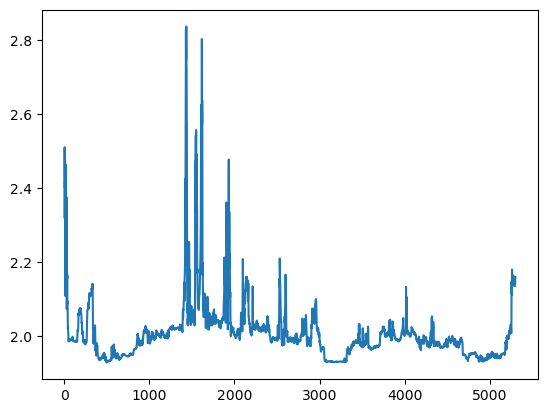

In [11]:
picarro_flight[' CH4_ppm'].plot()

What do we see? Well the y axis, $CH_4$ looks pretty reasonable. ~1.9-3ppm is in the range of normal for $CH_4$. But what is happening on the x axis? The x axis is just showing the data in order. We can tell from looking at the `Start_Time` column of our dataframe that the data are organized in chronological order, following the flight track. So we are seeing the observed values of $CH_4$ over the course of this flight. That's all looking normal so far, so let's move onto to some new operations.

_Do you wish that the x axis would show the time instead of the row number? Hang tight until the "Setting an Index" section to make that dream come true._

## Filtering

So let's start with a general question.  We learned about booleans and comparisons on Monday of this week.
> What would happen if we used a comparison on a pandas dataframe?

Give this a think:
`water_vars['discharge'] == 8.1`

The answer?  We get another dataframe. This dataframe is the size and shape as the thing used in comparison, but it is full of Boolean values telling us if the comparsion was true.

So what is the use of a list of booleans?  Let's start with a simplified list of booleans and experiment.

In [12]:
import random

In [13]:
# Create just a list of booleans, instead of a full dataframe
random_booleans = [random.choice([True, False]) for x in range(5303)]

In [14]:
# Use the list of booleans with square brackets, sort of like a key in a dictionary
picarro_flight[random_booleans]

,datetime (UTC),Time_Start,Time_Stop,CO2_ppm,CH4_ppm,H2O_ppm,CO_ppb,GPS_Alt,GPS_Lon,GPS_Lat
1,2024-07-02 15:00:54,54053.78,54055.78,458.760,2.37453,17212.0,335.1,413.698873,-117.639068,34.035502
2,2024-07-02 15:00:56,54055.78,54057.78,460.070,2.41431,17171.0,303.1,428.501557,-117.638719,34.034044
3,2024-07-02 15:00:58,54057.78,54059.78,462.200,2.50937,17072.0,302.0,443.528247,-117.638157,34.032327
4,2024-07-02 15:01:00,54059.78,54061.78,462.323,2.42580,17204.0,299.7,467.734623,-117.637646,34.030759
...,...,...,...,...,...,...,...,...,...,...
5299,2024-07-02 17:57:30,64649.78,64651.78,453.916,2.14152,16617.0,313.5,327.524082,-117.583783,34.056886
5300,2024-07-02 17:57:32,64651.78,64653.78,454.102,2.14418,17055.0,319.5,320.590900,-117.585301,34.056888
5301,2024-07-02 17:57:34,64653.78,64655.78,455.835,2.14418,17055.0,330.2,313.019498,-117.586845,34.056888
5302,2024-07-02 17:57:36,64655.78,64657.78,455.938,2.15877,17167.0,331.4,306.001105,-117.588324,34.056887


That returned only the rows where the value in the list was True!  

This is exciting, because this is the basis for filtering rows in `pandas`.  Trying it again with our conditional statement from above `water_vars['dissolved oxygen'] == 8.2`:

In [15]:
picarro_flight

,datetime (UTC),Time_Start,Time_Stop,CO2_ppm,CH4_ppm,H2O_ppm,CO_ppb,GPS_Alt,GPS_Lon,GPS_Lat
0,2024-07-02 15:00:52,54051.78,54053.78,458.790,2.32010,17173.0,335.3,389.879753,-117.639455,34.037073
1,2024-07-02 15:00:54,54053.78,54055.78,458.760,2.37453,17212.0,335.1,413.698873,-117.639068,34.035502
2,2024-07-02 15:00:56,54055.78,54057.78,460.070,2.41431,17171.0,303.1,428.501557,-117.638719,34.034044
3,2024-07-02 15:00:58,54057.78,54059.78,462.200,2.50937,17072.0,302.0,443.528247,-117.638157,34.032327
...,...,...,...,...,...,...,...,...,...,...
5299,2024-07-02 17:57:30,64649.78,64651.78,453.916,2.14152,16617.0,313.5,327.524082,-117.583783,34.056886
5300,2024-07-02 17:57:32,64651.78,64653.78,454.102,2.14418,17055.0,319.5,320.590900,-117.585301,34.056888
5301,2024-07-02 17:57:34,64653.78,64655.78,455.835,2.14418,17055.0,330.2,313.019498,-117.586845,34.056888
5302,2024-07-02 17:57:36,64655.78,64657.78,455.938,2.15877,17167.0,331.4,306.001105,-117.588324,34.056887


In [16]:
# make a dataframe indicating where dissolved oxygen == 8.2
boolean_dataframe = picarro_flight[' CH4_ppm'] > 2.2

In [17]:
# returns only the rows where dissolved oxygen == 8.2
picarro_flight[boolean_dataframe]

,datetime (UTC),Time_Start,Time_Stop,CO2_ppm,CH4_ppm,H2O_ppm,CO_ppb,GPS_Alt,GPS_Lon,GPS_Lat
0,2024-07-02 15:00:52,54051.78,54053.78,458.790,2.32010,17173.0,335.3,389.879753,-117.639455,34.037073
1,2024-07-02 15:00:54,54053.78,54055.78,458.760,2.37453,17212.0,335.1,413.698873,-117.639068,34.035502
2,2024-07-02 15:00:56,54055.78,54057.78,460.070,2.41431,17171.0,303.1,428.501557,-117.638719,34.034044
3,2024-07-02 15:00:58,54057.78,54059.78,462.200,2.50937,17072.0,302.0,443.528247,-117.638157,34.032327
...,...,...,...,...,...,...,...,...,...,...
1944,2024-07-02 16:05:40,57939.78,57941.78,453.157,2.22177,11094.0,182.7,105.505902,-115.421393,33.110432
2097,2024-07-02 16:10:46,58245.78,58247.78,445.517,2.20064,12216.0,163.3,105.562942,-115.426698,33.052851
2098,2024-07-02 16:10:48,58247.78,58249.78,444.504,2.20760,12141.0,164.5,106.693839,-115.427742,33.051837
2532,2024-07-02 16:25:16,59115.78,59117.78,429.246,2.20904,13983.0,123.5,171.185377,-115.320763,32.758445


While there are several steps, this process is most commonly done in a single step:

In [18]:
picarro_flight[picarro_flight[' CH4_ppm'] > 2.2]

,datetime (UTC),Time_Start,Time_Stop,CO2_ppm,CH4_ppm,H2O_ppm,CO_ppb,GPS_Alt,GPS_Lon,GPS_Lat
0,2024-07-02 15:00:52,54051.78,54053.78,458.790,2.32010,17173.0,335.3,389.879753,-117.639455,34.037073
1,2024-07-02 15:00:54,54053.78,54055.78,458.760,2.37453,17212.0,335.1,413.698873,-117.639068,34.035502
2,2024-07-02 15:00:56,54055.78,54057.78,460.070,2.41431,17171.0,303.1,428.501557,-117.638719,34.034044
3,2024-07-02 15:00:58,54057.78,54059.78,462.200,2.50937,17072.0,302.0,443.528247,-117.638157,34.032327
...,...,...,...,...,...,...,...,...,...,...
1944,2024-07-02 16:05:40,57939.78,57941.78,453.157,2.22177,11094.0,182.7,105.505902,-115.421393,33.110432
2097,2024-07-02 16:10:46,58245.78,58247.78,445.517,2.20064,12216.0,163.3,105.562942,-115.426698,33.052851
2098,2024-07-02 16:10:48,58247.78,58249.78,444.504,2.20760,12141.0,164.5,106.693839,-115.427742,33.051837
2532,2024-07-02 16:25:16,59115.78,59117.78,429.246,2.20904,13983.0,123.5,171.185377,-115.320763,32.758445


<Axes: >

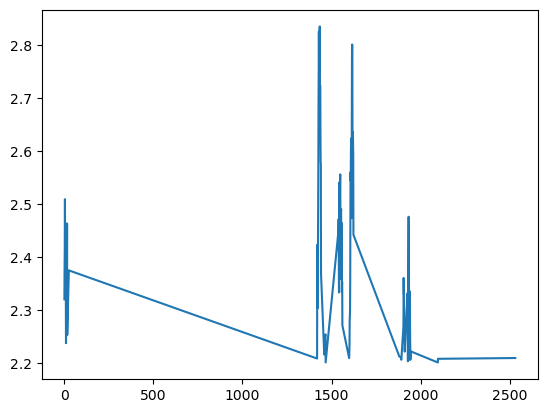

In [19]:
picarro_flight[picarro_flight[' CH4_ppm'] > 2.2][' CH4_ppm'].plot()

What's happening in this sanity check plot? Well we can see that our filter worked because there aren't any values below 2.2. But what is happening in betweeen? In a line plot pandas is going to connect each value to the next value with a line. The lines are connecting across the regions that now don't have any data in them, making them look odd.

If you just wanted a simple plot to make sure that all the values are above 2.2 then the plot above does that job. If you'd like it to look a little neater you can use the `style` argument with a value of `'.'`. This tells pandas to render little dots instead of connecting each observation with a line.

<Axes: >

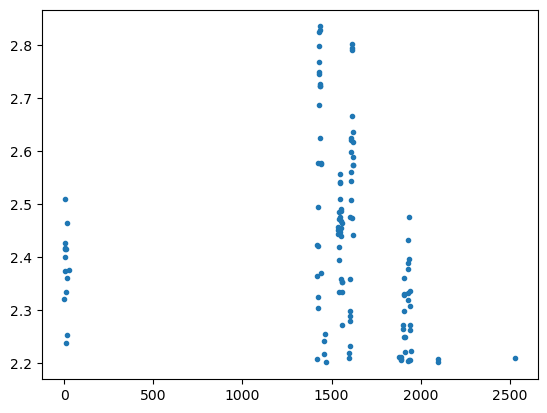

In [20]:
picarro_flight[picarro_flight[' CH4_ppm'] > 2.2][' CH4_ppm'].plot(style='.')

:::{admonition} 📝 Check your understanding
:class: tip

Write a cell of code that returns only the rows of the `water_vars` dataframe where discharge is less than or equal to 46.

:::

### Using `and` and `or`

You can continue to make your filter more specific by using multiple filters.  The syntax that we used in the first lesson was:

In [21]:
num_cats = 3
num_dogs = 2
print(num_cats > 2 and num_dogs > 2)
print(num_cats > 2 or num_dogs > 2)

False
True


While the meaning of `and` and `or` is the same in `pandas`, the syntax is slightly different.  In pandas:

| Python      | Pandas |
| :-----------: | :-----------: |
| and      | &       |
| or   | &#124;       |

You also have to be sure to wrap each individual conditional statement in parenthesis `()`.

In [22]:
picarro_flight

,datetime (UTC),Time_Start,Time_Stop,CO2_ppm,CH4_ppm,H2O_ppm,CO_ppb,GPS_Alt,GPS_Lon,GPS_Lat
0,2024-07-02 15:00:52,54051.78,54053.78,458.790,2.32010,17173.0,335.3,389.879753,-117.639455,34.037073
1,2024-07-02 15:00:54,54053.78,54055.78,458.760,2.37453,17212.0,335.1,413.698873,-117.639068,34.035502
2,2024-07-02 15:00:56,54055.78,54057.78,460.070,2.41431,17171.0,303.1,428.501557,-117.638719,34.034044
3,2024-07-02 15:00:58,54057.78,54059.78,462.200,2.50937,17072.0,302.0,443.528247,-117.638157,34.032327
...,...,...,...,...,...,...,...,...,...,...
5299,2024-07-02 17:57:30,64649.78,64651.78,453.916,2.14152,16617.0,313.5,327.524082,-117.583783,34.056886
5300,2024-07-02 17:57:32,64651.78,64653.78,454.102,2.14418,17055.0,319.5,320.590900,-117.585301,34.056888
5301,2024-07-02 17:57:34,64653.78,64655.78,455.835,2.14418,17055.0,330.2,313.019498,-117.586845,34.056888
5302,2024-07-02 17:57:36,64655.78,64657.78,455.938,2.15877,17167.0,331.4,306.001105,-117.588324,34.056887


In [23]:
# Cells where pH < 8 and dam release was True
picarro_flight[(picarro_flight[' CH4_ppm'] > 2) & (picarro_flight[' CO2_ppm'] < 440)]

,datetime (UTC),Time_Start,Time_Stop,CO2_ppm,CH4_ppm,H2O_ppm,CO_ppb,GPS_Alt,GPS_Lon,GPS_Lat
38,2024-07-02 15:02:08,54127.78,54129.78,439.095,2.07115,14441.0,198.6,764.617646,-117.594656,34.002401
39,2024-07-02 15:02:10,54129.78,54131.78,432.902,2.04689,13602.0,164.2,787.966822,-117.592941,34.001951
40,2024-07-02 15:02:12,54131.78,54133.78,430.113,2.02776,12941.0,180.8,809.645831,-117.591265,34.001496
41,2024-07-02 15:02:14,54133.78,54135.78,432.392,2.01841,12095.0,190.7,829.670768,-117.589655,34.001055
...,...,...,...,...,...,...,...,...,...,...
5253,2024-07-02 17:55:58,64557.78,64559.78,431.925,2.01713,11284.0,178.2,728.306846,-117.496191,34.056706
5254,2024-07-02 17:56:00,64559.78,64561.78,432.113,2.01684,11257.0,157.5,719.288783,-117.498544,34.056692
5255,2024-07-02 17:56:02,64561.78,64563.78,432.144,2.00731,11370.0,152.3,710.368556,-117.500843,34.056692
5256,2024-07-02 17:56:04,64563.78,64565.78,432.524,2.03067,12158.0,250.5,701.251764,-117.503202,34.056705


In [24]:
picarro_flight[(picarro_flight[' CH4_ppm'] > 2) | (picarro_flight[' CO2_ppm'] < 440)]

,datetime (UTC),Time_Start,Time_Stop,CO2_ppm,CH4_ppm,H2O_ppm,CO_ppb,GPS_Alt,GPS_Lon,GPS_Lat
0,2024-07-02 15:00:52,54051.78,54053.78,458.790,2.32010,17173.0,335.3,389.879753,-117.639455,34.037073
1,2024-07-02 15:00:54,54053.78,54055.78,458.760,2.37453,17212.0,335.1,413.698873,-117.639068,34.035502
2,2024-07-02 15:00:56,54055.78,54057.78,460.070,2.41431,17171.0,303.1,428.501557,-117.638719,34.034044
3,2024-07-02 15:00:58,54057.78,54059.78,462.200,2.50937,17072.0,302.0,443.528247,-117.638157,34.032327
...,...,...,...,...,...,...,...,...,...,...
5299,2024-07-02 17:57:30,64649.78,64651.78,453.916,2.14152,16617.0,313.5,327.524082,-117.583783,34.056886
5300,2024-07-02 17:57:32,64651.78,64653.78,454.102,2.14418,17055.0,319.5,320.590900,-117.585301,34.056888
5301,2024-07-02 17:57:34,64653.78,64655.78,455.835,2.14418,17055.0,330.2,313.019498,-117.586845,34.056888
5302,2024-07-02 17:57:36,64655.78,64657.78,455.938,2.15877,17167.0,331.4,306.001105,-117.588324,34.056887


There is more than one way to do this type of filtering in pandas, but it is fine to start with one method and feel really comfortable with it before moving to the others.  [This article](https://www.listendata.com/2019/07/how-to-filter-pandas-dataframe.html) has a pretty nice overview of some other methods.

:::{admonition} 📝 Check your understanding
:class: tip

How is the following line of code filtering the `water_vars` dataset?

`water_vars[(water_vars['discharge'] <= 46) | (water_vars['dam release'] > 42)]`

:::

## Setting a column as an Index

We've seen indexes as part of lists, and now we are about to see them as part of a pandas dataframe. An index serves the same role in both cases -- it helps us uniquely identify a row in a dataframe.

Whether using pandas or excel or a SQL database, the index is an important part of your organization.  
> The most important part of in index is that it is **unique**, meaning no two rows of data is allowed to have the same index

This is important for keeping the data organized, not just practically but also conceptually.

So for in our coding instruction an index has only been allowed to be a number: 0, 1, 2, 3, ... Pandas lets us do something a bit different and lets us use other data types, like strings, as an index instead. Let's look at an example of this with this dataframe:

In [31]:
grades = pd.DataFrame(
    {
        'name': ['Beatriz S', 'Joel H', 'Lashandra T', 'Ari T', 'Hassan A'],
        'history': [78, 69, 80, 91, 79],
        'science': [85, 80, 80, 73, 91],
        'music': [81, 81, 90, 73, 89],
    }
)

In [32]:
grades

,name,history,science,music
0,Beatriz S,78,85,81
1,Joel H,69,80,81
2,Lashandra T,80,80,90
3,Ari T,91,73,73
4,Hassan A,79,91,89


In this dataframe we have default indexes of 0 -> 4 set.  We could pretty smoothly use these if we wanted and just know in our heads that Beatriz is index 0, Sara is index 1 and so on.

Alternatively, we could skip the step of remembering index numbers and just use the names of the students as the index.  We do that with the `.set_index()` method.

In [33]:
grades.set_index('name')

,history,science,music
name,,,
Beatriz S,78,85,81
Joel H,69,80,81
Lashandra T,80,80,90
Ari T,91,73,73
Hassan A,79,91,89


In [34]:
# update the original dataframe with the new index
grades = grades.set_index('name')

Now we can get the grades of a student using the syntax `.loc[]`:

In [35]:
grades.loc['Joel H']

history    69
science    80
music      81
Name: Joel H, dtype: int64

### `.iloc` vs. `loc`

So now that we have names as indexes, how do we select specific rows?

We can still use the same method we already know, `iloc`, with an integer index number and we will still get the same result.

In [29]:
grades.iloc[1]

history    69
science    80
music      81
Name: Joel H, dtype: int64

Alternatively we can also use a similar but slightly different method - `.loc`.  `.loc` allows us to find specific rows based on an index label, not the integer.

In [30]:
grades.loc['Hassan A']

history    79
science    91
music      89
Name: Hassan A, dtype: int64

If you want a deep dive on `.iloc` vs. `.loc` [this article](https://towardsdatascience.com/how-to-use-loc-and-iloc-for-selecting-data-in-pandas-bd09cb4c3d79) is for you.

:::{admonition} 📝 Check your understanding
:class: tip

Write 2 lines of code to get Ari's grades the grades dataframe. In one line use `.iloc` and in the other use `.loc`. 

Explain to your partner the difference between `.iloc` and `.loc`.

:::

### One more example - datetime indices

To move away from our toy example baack to our real data, we have a great column in the `water_vars` table just waiting to be an index -- `datetime`.

Dates and times are generally fantastic indices, because, if the world is working in proper order, each moment in time only happens once, meaning their values are unique and they are really common indices.

In [119]:
picarro_flight = picarro_flight.set_index('datetime (UTC)')

In [120]:
picarro_flight

,Time_Start,Time_Stop,CO2_ppm,CH4_ppm,H2O_ppm,CO_ppb,GPS_Alt,GPS_Lon,GPS_Lat
datetime (UTC),,,,,,,,,
2024-07-02 15:00:52,54051.78,54053.78,458.790,2.32010,17173.0,335.3,389.879753,-117.639455,34.037073
2024-07-02 15:00:54,54053.78,54055.78,458.760,2.37453,17212.0,335.1,413.698873,-117.639068,34.035502
2024-07-02 15:00:56,54055.78,54057.78,460.070,2.41431,17171.0,303.1,428.501557,-117.638719,34.034044
2024-07-02 15:00:58,54057.78,54059.78,462.200,2.50937,17072.0,302.0,443.528247,-117.638157,34.032327
2024-07-02 15:01:00,54059.78,54061.78,462.323,2.42580,17204.0,299.7,467.734623,-117.637646,34.030759
...,...,...,...,...,...,...,...,...,...
2024-07-02 17:57:28,64647.78,64649.78,453.317,2.13683,16550.0,311.7,335.601082,-117.582164,34.056872
2024-07-02 17:57:30,64649.78,64651.78,453.916,2.14152,16617.0,313.5,327.524082,-117.583783,34.056886
2024-07-02 17:57:32,64651.78,64653.78,454.102,2.14418,17055.0,319.5,320.590900,-117.585301,34.056888


In [57]:
picarro_flight.loc['2024-07-02 15:00:56']

Time_Start    54055.780000
 Time_Stop    54057.780000
 CO2_ppm        460.070000
 CH4_ppm          2.414310
 H2O_ppm      17171.000000
 CO_ppb         303.100000
 GPS_Alt        428.501557
 GPS_Lon       -117.638719
 GPS_Lat         34.034044
Name: 2024-07-02 15:00:56, dtype: float64

Another benefit of setting the index is that it makes our plots a little cleaner. Remember how that first plot in the lesson of Methane vs. Time showed a generic row number on the x axis? Checkout what happens on that the index is a datetime:

<Axes: xlabel='datetime (UTC)'>

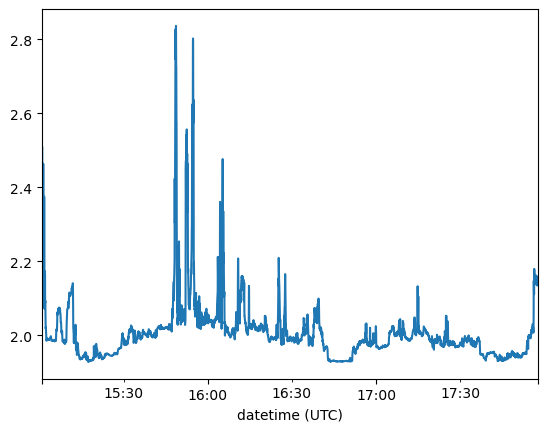

In [59]:
picarro_flight[' CH4_ppm'].plot()

Beautiful! A much more readable x axis.

:::{admonition} 📝 Check your understanding
:class: tip

Write a line of code to get the row corresponding to March 13th 2021 at 8:00am.

:::

## Groupby

While we have 146 individual readings in our dataset sometimes we don't care about each individual reading.  Instead we probably care about the aggregate of a specific group of readings. 

For example:
* Given the average temperature of every county in the US, what is the average temperature in each state?
* Given a list of the opening dates of every Chuck E Cheese stores, how many Chuck E Cheeses were opened each year? 🧀

In pandas (and tabular data in general) we answer questions like that that with `groupby`.

### Breaking `groupby` into conceptual parts

In addition to the dataframe, there are three main parts to a groupby:
1. Which variable we want to group together
2. How we want to group
3. The variable we want to see in the end

Without getting into syntax yet we can start by identifiying these in our two example questions.

**Given the average temperature of every county in the US, what is the average temperature in each state?**

* _Which variable to group together?_ -> We want to group counties into states
* _How do we want to group?_ -> Take the average
* _What variable do we want to look at?_ Temperature

**Given a list of the opening dates of every Chuck E Cheese stores, how many Chuck E Cheeses were opened each year?**

* _Which variable to group together?_ -> We want to group individual days into years
* _How do we want to group?_ -> Count them
* _What variable do we want to look at?_ Number of stores

:::{admonition} 📝 Check your understanding
:class: tip

Identify each of three main groupby parts in the following scenario:

**Given the hourly temperatures for a location over the course of a month, what were the daily highs?**

1. _Which variable to group together?_
2. _How do we want to group?_
3. _What variable do we want to look at?_

:::

### Pre-processing

The code below adds to new columns "CO2_rating", and "CH4_rating" to the dataframe. These classify the $CO_2$ and $CO_4$ measurements qualitatively instead of quantitatively so we can experiment with using groupby. Don't worry too much about the code below, but notice the new columns at the end of the dataframe.

In [121]:
# Define cutoffs for the carbon dioxide and methane ratings
bins_co2 = [float('-inf'), 430, 440, float('inf')]
bins_ch4 = [float('-inf'), 2.0, 2.3, float('inf')]
labels = ['low', 'medium', 'high']

In [127]:
# Add carbon dioxide rating
picarro_flight['CO2_rating'] = pd.cut(
    picarro_flight[' CO2_ppm'], bins=bins_co2, 
    labels=labels, include_lowest=True
).astype('str')

In [134]:
picarro_flight['CH4_rating']

datetime (UTC)
2024-07-02 15:00:52      high
2024-07-02 15:00:54      high
2024-07-02 15:00:56      high
2024-07-02 15:00:58      high
2024-07-02 15:01:00      high
                        ...  
2024-07-02 17:57:28    medium
2024-07-02 17:57:30    medium
2024-07-02 17:57:32    medium
2024-07-02 17:57:34    medium
2024-07-02 17:57:36    medium
Name: CH4_rating, Length: 5303, dtype: object

In [133]:
# Add methane rating
picarro_flight['CH4_rating'] = pd.cut(
    picarro_flight[' CH4_ppm'], bins=bins_ch4, 
    labels=labels, include_lowest=True
).astype('str')

In [ ]:
# Drop unneeded columns for the next exercise
picarro_flight.drop(
    ['Time_Start', ' Time_Stop', ' GPS_Lon', ' GPS_Lat'], axis=1, inplace=True
)

### `groupby` syntax

We can take these `groupby` concepts and translate them into syntax.  The first two parts (which variable to group & how do we want to group) are required for pandas.  The third one is optional.

Starting with just the two required variables, the general syntax is:

`DATAFRAME.groupby(WHICH_GROUP).AGGREGATION()`

Words in all capitals are variables.  We'll go into each part a little more below.

In [111]:
picarro_flight

 CO2_ppm       float64
 CH4_ppm       float64
 H2O_ppm       float64
 CO_ppb        float64
 GPS_Alt       float64
CO2_rating    category
CH4_rating    category
dtype: object

In [137]:
picarro_flight.groupby("CO2_rating").mean(numeric_only=True)

,CO2_ppm,CH4_ppm,H2O_ppm,CO_ppb,GPS_Alt
CO2_rating,,,,,
high,450.436554,2.192665,15200.166311,196.034755,261.402532
low,426.565941,1.967308,6102.602509,103.925914,1078.394145
medium,433.416890,2.019003,12846.384051,146.918542,171.895462


What do we see in the output?
- Which (if any) of the other species are directly correlated with carbon dioxide?
- Are the highest $CO_2$ values near the surface or higher up?

#### `'WHICH_GROUP'`

This variable can be any of the columns in the dataframe that can be put into discrete piles.  We used `'safety_level'` because it can easily be put into piles -- `low`, `medium` and `high`.

We are still allowed to group on other columns, it's just that the practicality can become questionable.

In [138]:
picarro_flight.groupby("CH4_rating").min(numeric_only=True)

,CO2_ppm,CH4_ppm,H2O_ppm,CO_ppb,GPS_Alt
CH4_rating,,,,,
high,440.061,2.30336,10057.0,131.0,49.318883
low,419.591,1.92809,1080.0,57.3,18.900000
medium,425.214,2.00006,4060.0,97.8,-7.338963


:::{note}

Because they are right next to each other it can be really tempting to want to put the variable you are most interested in seeing in place of `WHICH_GROUP`.  If you do this and use a column that can't be grouped, so consider the `WHICH_GROUP` variable if you are debugging.

:::

#### Aggregation Functions 

The functions you can use in a groupby are limited, but there are still lots of options.  Common ones include:
* `.count()` - find the total number of rows
* `.min()`- find the minimum value of those rows
* `.max()` - find the maximum value of those rows
* `.mean()`- find the mean value of those rows
* `.sum()` - find the sum of the values of those rows

In [142]:
picarro_flight.groupby("CH4_rating").count()

,CO2_ppm,CH4_ppm,H2O_ppm,CO_ppb,GPS_Alt,CO2_rating
CH4_rating,,,,,,
high,89,89,89,89,89,89
low,3072,3072,3072,3072,3072,3072
medium,2142,2142,2142,2142,2142,2142


#### The third input

In the conceptual explanation we often also specify which variable we want to look at.  In `pandas` this isn't always as important, since by default it gives us the full dataframe.  If for some reason we do need to specify the exact variable of interest (ex. we have a very large dataframe, we are making a plot), we do that by adding the column name in after the groupby.

`DATAFRAME.groupby(WHICH_GROUP)[INTEREST_VAR].AGGREGATION()`

In [140]:
# Group our water dataframe by saftey level and take the mean of the discharge values for each safety level group
picarro_flight.groupby("CO2_rating")[' CH4_ppm'].mean()

CO2_rating
high      2.192665
low       1.967308
medium    2.019003
Name:  CH4_ppm, dtype: float64

:::{admonition} 📝 Check your understanding
:class: tip

1. What is the maximum pH value during low safety level?

2. What is the mean discharge when dam releases are happening?

:::

### Breaking down the process

There is a lot that happens in a single step with `groupby` and it can be a lot to take in.  One way to mentally situate this process is to think about **split-apply-combine**.

**split-apply-combine** breaks down the `groupby` process into those three steps:
1. SPLIT the full data set into groups.  Split is related to the question _Which variable to group together?_
2. APPLY the aggregation function to the individual groups.  Apply is related to the question _How do we want to group?_
3. COMBINE the aggregated data into a new dataframe


<img src="https://static.packt-cdn.com/products/9781783985128/graphics/5128OS_09_01.jpg" width=550>




